In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

# Load the results
RESULTS_FILE = "grid_search_results_no_shap_100.json"

with open(RESULTS_FILE) as f:
    data = json.load(f)

print(f"Loaded results from: {RESULTS_FILE}")
print(f"Timestamp: {data['timestamp']}")
print(f"Number of folds: {data['n_folds']}")
print(f"Number of experiments: {len(data['results'])}")
print(f"Use SHAP: {data['use_shap']}")
print(f"Use LightGBM defaults: {data['use_lightgbm_default']}")


Loaded results from: grid_search_results_no_shap_100.json
Timestamp: 2025-12-12T00:05:09.128313
Number of folds: 10
Number of experiments: 72
Use SHAP: False
Use LightGBM defaults: False


## Convert to DataFrame

Create a summary dataframe with mean and std of metrics across folds for each parameter configuration.


In [2]:
# Build summary dataframe
rows = []
for exp in data['results']:
    params = exp['full_params']
    fold_results = exp['fold_results']
    
    train_mses = [f['train_mse'] for f in fold_results]
    test_mses = [f['test_mse'] for f in fold_results]
    
    row = {
        # Parameters (only varying ones)
        'drop_rate': params.get('drop_rate'),
        'feature_fraction_bynode': params.get('feature_fraction_bynode'),
        'learning_rate': params.get('learning_rate'),
        'num_leaves': params.get('num_leaves'),
        'max_depth': params.get('max_depth'),
        # Metrics
        'train_mse_mean': np.mean(train_mses),
        'train_mse_std': np.std(train_mses),
        'test_mse_mean': np.mean(test_mses),
        'test_mse_std': np.std(test_mses),
        'test_mse_min': np.min(test_mses),
        'test_mse_max': np.max(test_mses),
        # Overfitting indicator
        'overfit_ratio': np.mean(test_mses) / np.mean(train_mses),
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Summary dataframe shape: {df.shape}")
df.head(10)


Summary dataframe shape: (72, 12)


,drop_rate,feature_fraction_bynode,learning_rate,num_leaves,max_depth,train_mse_mean,train_mse_std,test_mse_mean,test_mse_std,test_mse_min,test_mse_max,overfit_ratio
0,0.025,0.2,0.1,50,10,7.358428,5.298577,39.265727,22.778743,9.832305,73.958472,5.336157
1,0.025,0.2,0.1,100,10,5.717604,5.303620,37.673574,22.666398,6.653563,72.105690,6.589049
2,0.025,0.2,0.1,200,10,5.239406,5.256312,36.965600,22.158761,8.727653,76.044581,7.055303
3,0.025,0.2,0.2,50,10,2.918109,1.000187,34.679669,20.701333,9.289927,71.197798,11.884293
4,0.025,0.2,0.2,100,10,1.790978,0.998066,34.464173,21.230477,8.325210,67.944564,19.243210
5,0.025,0.2,0.2,200,10,1.457853,1.019511,34.766691,21.222667,8.561031,71.585461,23.847875
6,0.025,0.2,0.3,50,10,2.174346,0.379913,38.428170,22.068587,12.108341,71.906600,17.673442
7,0.025,0.2,0.3,100,10,1.188960,0.320899,36.811787,22.662920,10.618578,73.419093,30.961325
8,0.025,0.2,0.3,200,10,0.885573,0.340405,37.841616,21.977801,12.969992,70.142843,42.731212
9,0.025,0.4,0.1,50,10,6.852405,5.302914,38.620967,23.051036,9.439210,73.544101,5.636118


## Overall Statistics


In [3]:
df[['train_mse_mean', 'test_mse_mean', 'test_mse_std', 'overfit_ratio']].describe()


,train_mse_mean,test_mse_mean,test_mse_std,overfit_ratio
count,72.000000,72.000000,72.000000,72.000000
mean,7.482079,42.064725,27.767383,12.577636
std,7.758678,8.314675,7.267097,10.349651
min,0.742059,34.464173,18.168976,2.360784
25%,2.182994,36.864377,22.691864,4.981547
50%,4.299026,38.313344,25.128866,9.232072
75%,8.881125,43.947322,30.431416,17.142262
max,25.170187,59.421377,43.504130,50.305903


## Best Configurations

Top 10 configurations ranked by mean test MSE (lower is better).


In [4]:
best_configs = df.sort_values('test_mse_mean').head(10)
best_configs[['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves', 
              'test_mse_mean', 'test_mse_std', 'train_mse_mean', 'overfit_ratio']]


,drop_rate,feature_fraction_bynode,learning_rate,num_leaves,test_mse_mean,test_mse_std,train_mse_mean,overfit_ratio
4,0.025,0.2,0.2,100,34.464173,21.230477,1.790978,19.243210
3,0.025,0.2,0.2,50,34.679669,20.701333,2.918109,11.884293
5,0.025,0.2,0.2,200,34.766691,21.222667,1.457853,23.847875
69,0.200,0.4,0.3,50,34.812044,21.893559,3.073550,11.326330
12,0.025,0.4,0.2,50,35.055906,20.140019,2.540252,13.800170
15,0.025,0.4,0.3,50,35.070193,18.168976,1.851008,18.946542
61,0.200,0.2,0.3,100,35.197642,23.402383,2.255905,15.602446
13,0.025,0.4,0.2,100,35.526468,22.072187,1.571416,22.607933
24,0.050,0.2,0.3,50,35.975387,19.565606,2.522717,14.260572
70,0.200,0.4,0.3,100,35.980014,23.104488,2.053881,17.518063


## Worst Configurations

Bottom 10 configurations ranked by mean test MSE.


In [5]:
worst_configs = df.sort_values('test_mse_mean', ascending=False).head(10)
worst_configs[['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves', 
               'test_mse_mean', 'test_mse_std', 'train_mse_mean', 'overfit_ratio']]


,drop_rate,feature_fraction_bynode,learning_rate,num_leaves,test_mse_mean,test_mse_std,train_mse_mean,overfit_ratio
54,0.2,0.2,0.1,50,59.421377,35.616876,25.170187,2.360784
63,0.2,0.4,0.1,50,59.213049,33.363724,24.499039,2.416954
36,0.1,0.2,0.1,50,59.069012,43.397511,24.484585,2.412498
65,0.2,0.4,0.1,200,58.620199,34.354063,21.692785,2.702290
47,0.1,0.4,0.1,200,58.169594,42.201882,21.289868,2.732267
45,0.1,0.4,0.1,50,58.086131,41.671597,23.837256,2.436779
38,0.1,0.2,0.1,200,58.042138,42.869953,21.697479,2.675064
37,0.1,0.2,0.1,100,57.807300,41.783292,22.266530,2.596152
64,0.2,0.4,0.1,100,57.154549,34.345332,22.269758,2.566465
56,0.2,0.2,0.1,200,56.914030,34.441047,22.181322,2.565854


## Parameter Impact Analysis

Average test MSE for each parameter value to understand which settings tend to perform better.


In [6]:
param_cols = ['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves']

print("Mean Test MSE by Parameter Value:\n")
for param in param_cols:
    grouped = df.groupby(param)['test_mse_mean'].agg(['mean', 'std', 'count'])
    grouped = grouped.sort_values('mean')
    print(f"=== {param} ===")
    print(grouped.round(2))
    print()


Mean Test MSE by Parameter Value:

=== drop_rate ===
            mean    std  count
drop_rate                     
0.025      36.90   1.63     18
0.050      42.55   7.04     18
0.200      44.05  10.11     18
0.100      44.76   9.69     18

=== feature_fraction_bynode ===
                          mean   std  count
feature_fraction_bynode                    
0.2                      41.84  8.49     36
0.4                      42.29  8.25     36

=== learning_rate ===
                mean   std  count
learning_rate                    
0.3            36.77  0.98     24
0.2            37.94  1.96     24
0.1            51.49  8.31     24

=== num_leaves ===
             mean   std  count
num_leaves                    
100         41.48  8.16     24
50          42.18  8.87     24
200         42.54  8.21     24



## Visualizations


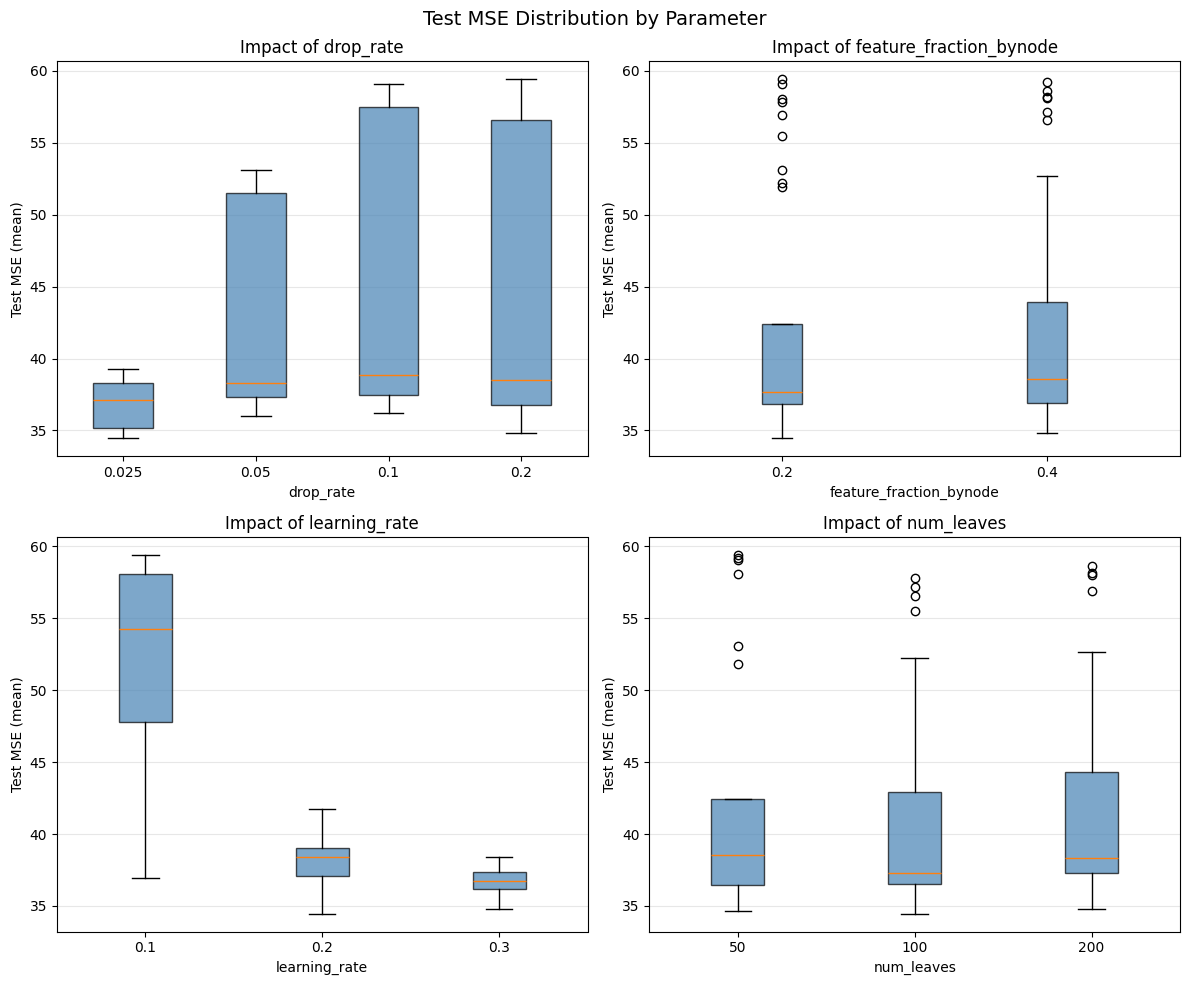

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Test MSE Distribution by Parameter', fontsize=14)

for ax, param in zip(axes.flat, param_cols):
    grouped = df.groupby(param)['test_mse_mean'].apply(list)
    box_data = [grouped[k] for k in sorted(grouped.index)]
    labels = [str(k) for k in sorted(grouped.index)]
    
    bp = ax.boxplot(box_data, tick_labels=labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    
    ax.set_xlabel(param)
    ax.set_ylabel('Test MSE (mean)')
    ax.set_title(f'Impact of {param}')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


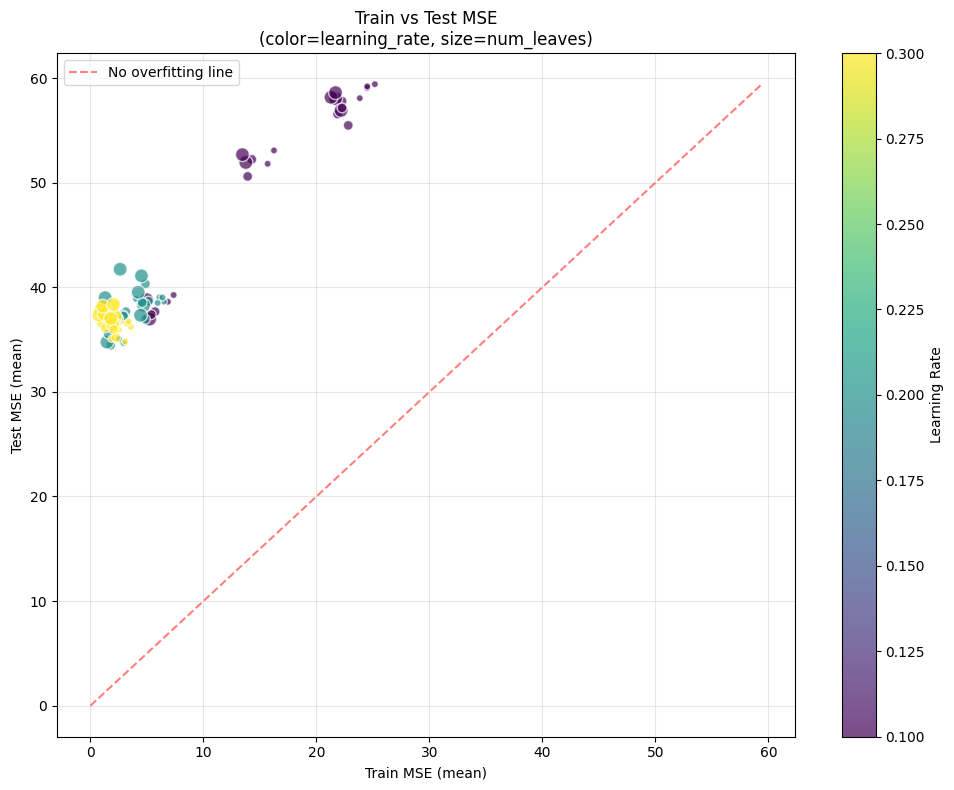

In [8]:
# Train vs Test MSE scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(df['train_mse_mean'], df['test_mse_mean'], 
                     c=df['learning_rate'], cmap='viridis', 
                     s=df['num_leaves']/2, alpha=0.7, edgecolors='white')

# Add diagonal line (perfect fit = no overfitting)
lims = [0, max(df['test_mse_mean'].max(), df['train_mse_mean'].max())]
ax.plot(lims, lims, 'r--', alpha=0.5, label='No overfitting line')

ax.set_xlabel('Train MSE (mean)')
ax.set_ylabel('Test MSE (mean)')
ax.set_title('Train vs Test MSE\n(color=learning_rate, size=num_leaves)')
ax.legend()
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Learning Rate')

plt.tight_layout()
plt.show()


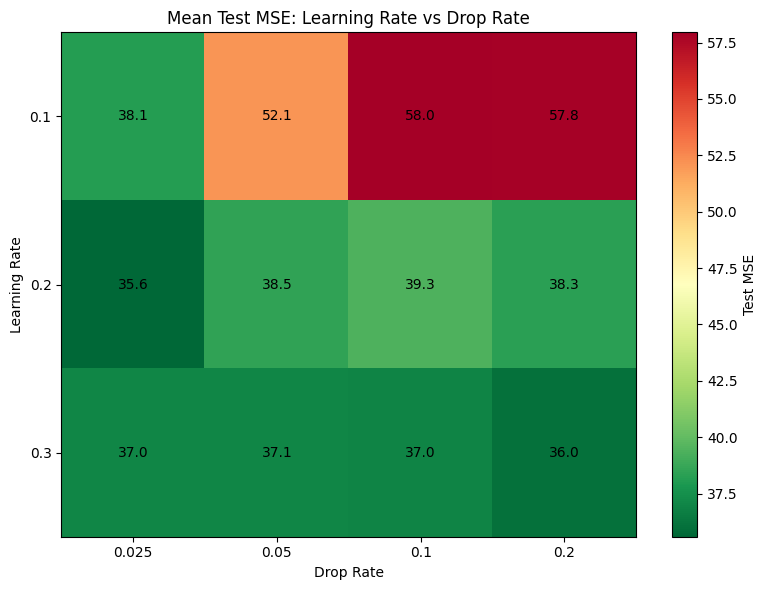

In [9]:
# Heatmap of learning_rate vs drop_rate
pivot = df.pivot_table(values='test_mse_mean', 
                       index='learning_rate', 
                       columns='drop_rate', 
                       aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Drop Rate')
ax.set_ylabel('Learning Rate')
ax.set_title('Mean Test MSE: Learning Rate vs Drop Rate')

# Add values to cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        text = ax.text(j, i, f'{pivot.values[i, j]:.1f}',
                       ha='center', va='center', color='black', fontsize=10)

plt.colorbar(im, label='Test MSE')
plt.tight_layout()
plt.show()


## Best Model Detailed Analysis

Detailed fold-by-fold results for the best configuration.


In [10]:
# Find the best model based on test_mse_mean
best_idx = df['test_mse_mean'].idxmin()
best_row = df.loc[best_idx]

# Find the corresponding raw data
best_params = {
    'drop_rate': best_row['drop_rate'],
    'feature_fraction_bynode': best_row['feature_fraction_bynode'],
    'learning_rate': best_row['learning_rate'],
    'num_leaves': best_row['num_leaves'],
}

# Find matching experiment in raw data
best_experiment = None
for exp in data['results']:
    params = exp['full_params']
    if (params.get('drop_rate') == best_params['drop_rate'] and
        params.get('feature_fraction_bynode') == best_params['feature_fraction_bynode'] and
        params.get('learning_rate') == best_params['learning_rate'] and
        params.get('num_leaves') == best_params['num_leaves']):
        best_experiment = exp
        break

print("Best Configuration Parameters:")
print("-" * 40)
for k, v in best_experiment['full_params'].items():
    print(f"  {k}: {v}")

print(f"\nOverall Performance:")
print("-" * 40)
print(f"  Mean Test MSE:  {best_row['test_mse_mean']:.4f}")
print(f"  Std Test MSE:   {best_row['test_mse_std']:.4f}")
print(f"  Mean Train MSE: {best_row['train_mse_mean']:.4f}")
print(f"  Overfit Ratio:  {best_row['overfit_ratio']:.4f}")


Best Configuration Parameters:
----------------------------------------
  objective: regression
  boosting_type: dart
  metric: mse
  verbose: -1
  max_depth: 10
  drop_rate: 0.025
  feature_fraction_bynode: 0.2
  learning_rate: 0.2
  num_leaves: 100

Overall Performance:
----------------------------------------
  Mean Test MSE:  34.4642
  Std Test MSE:   21.2305
  Mean Train MSE: 1.7910
  Overfit Ratio:  19.2432


Fold-by-Fold Results for Best Configuration:


,fold_idx,train_mse,test_mse,train_samples,test_samples,overfit_ratio
0,0,1.675783,51.858417,47226,6274,30.945792
1,1,1.210555,22.809568,47817,5683,18.842247
2,2,1.300735,67.944564,47671,5829,52.235522
3,3,1.395537,11.434957,48171,5329,8.193948
4,4,4.660889,28.595320,49353,4147,6.135164
5,5,1.215486,22.351697,47410,6090,18.389104
6,6,1.515388,54.526578,47771,5729,35.981936
7,7,1.211618,62.060068,49064,4436,51.220807
8,8,1.526316,8.325210,50015,3485,5.454447
9,9,2.197478,14.735352,47002,6498,6.705575


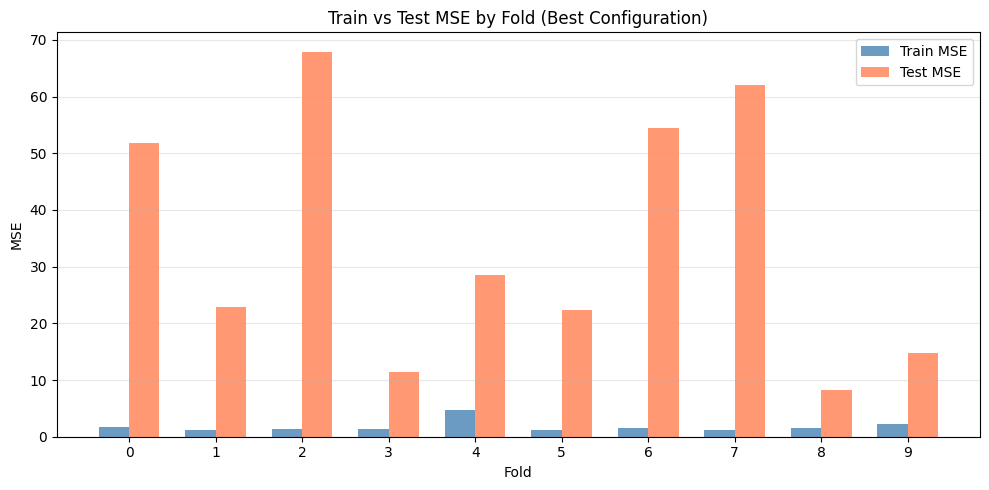

In [11]:
# Fold-level results for best model
fold_df = pd.DataFrame(best_experiment['fold_results'])
fold_df['overfit_ratio'] = fold_df['test_mse'] / fold_df['train_mse']

print("Fold-by-Fold Results for Best Configuration:")
print("=" * 60)
display(fold_df)

# Visualize fold results
fig, ax = plt.subplots(figsize=(10, 5))
x = fold_df['fold_idx']
width = 0.35

bars1 = ax.bar(x - width/2, fold_df['train_mse'], width, label='Train MSE', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, fold_df['test_mse'], width, label='Test MSE', color='coral', alpha=0.8)

ax.set_xlabel('Fold')
ax.set_ylabel('MSE')
ax.set_title('Train vs Test MSE by Fold (Best Configuration)')
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Summary Statistics


In [12]:
print("=" * 60)
print("GRID SEARCH SUMMARY")
print("=" * 60)
print(f"\nTotal configurations tested: {len(df)}")
print(f"Cross-validation folds: {data['n_folds']}")
print(f"\nTest MSE Statistics:")
print(f"  Best:  {df['test_mse_mean'].min():.4f}")
print(f"  Worst: {df['test_mse_mean'].max():.4f}")
print(f"  Mean:  {df['test_mse_mean'].mean():.4f}")
print(f"  Std:   {df['test_mse_mean'].std():.4f}")

print(f"\nBest parameters:")
for k in ['drop_rate', 'feature_fraction_bynode', 'learning_rate', 'num_leaves']:
    print(f"  {k}: {best_row[k]}")
print("=" * 60)


GRID SEARCH SUMMARY

Total configurations tested: 72
Cross-validation folds: 10

Test MSE Statistics:
  Best:  34.4642
  Worst: 59.4214
  Mean:  42.0647
  Std:   8.3147

Best parameters:
  drop_rate: 0.025
  feature_fraction_bynode: 0.2
  learning_rate: 0.2
  num_leaves: 100.0
